In [11]:
from srsinst.sr860 import SR860
import pyvisa
rm = pyvisa.ResourceManager()
rm.list_resources()


('USB0::0xB506::0x2000::006521::INSTR', 'ASRL1::INSTR', 'ASRL3::INSTR')

In [12]:
lockin = SR860('visa', 'USB0::0xB506::0x2000::006521::INSTR')
lockin.check_id()
print(lockin.get_status())

Frequency: 1.000000e+05 Hz
 Phase: 149.263243 deg
 Amplitude: 0.5000 V
 DC level: 0.0000 V
 Harmonic: 1

OK


In [13]:
lockin.ref.sine_out_amplitude = 500e-3

In [14]:
%pdb on

from DeviceInterface import DeviceInterface,DeviceStatus
from DeviceController import deviceControl
import time


def main():
    Set_Current =1#A
    Mode = "Constant Current"
    DeviceInterface.reset_limit_status()
    print("config_serialport")
    DeviceInterface.config_serialport("COM3")
    print("connect")
    if DeviceInterface.connect():
       #print("read_magnetic_field")
       #DeviceInterface.read_magnetic_field()
       #print(deviceControl.x_moved)
       print("electromagnet_on")
       DeviceInterface.electromagnet_on()
       print("Set Constant Current")
       DeviceInterface.set_field(Mode,Set_Current)
       time.sleep(5)   # sleeps for 5 seconds
       DeviceInterface.read_magnetic_field()
       print(deviceControl.x_moved)
       print("electromagnet_off")
       DeviceInterface.electromagnet_off()
       DeviceInterface.clear_comports()
    else:
       print("Device not connected")

 
      



main()

Automatic pdb calling has been turned ON
config_serialport
connect
electromagnet_on
Set Constant Current
282.7084
-99.1
electromagnet_off
Serial port closed successfully.


from DeviceInterface import DeviceInterface, DeviceStatus
from DeviceController import deviceControl
import time
import numpy as np
import matplotlib.pyplot as plt

def main():
    Mode = "Constant Current"

    start_current = -1.0
    stop_current = 1.0
    step = 0.1          # current increment
    settle_time = 1.0   # seconds to wait after each step

    # Create current sweep: -1.0, -0.9, ..., 1.0
    currents = np.arange(start_current, stop_current + step, step)

    DeviceInterface.reset_limit_status()
    DeviceInterface.config_serialport("COM3")

    if DeviceInterface.connect():
        DeviceInterface.electromagnet_on()

        try:
            with open("current_vs_field.txt", "w") as f:
                f.write("Current(A)\tMagneticField\n")

                for current in currents:
                    print(f"Setting current: {current:.2f} A")
                    DeviceInterface.set_field(Mode, current)
                    #print(f"Setting magnitude: {magnitude:.2f}")
                    

                    #time.sleep(settle_time)  # allow field to settle

                    #DeviceInterface.read_magnetic_field()

                    DeviceInterface.set_field(Mode,current)
                    time.sleep(1)   # sleeps for 5 seconds
                    mag_field = DeviceInterface.read_magnetic_field()
                    mag_field_1 = deviceControl.x_moved
                    print(f"Measured field: {mag_field_1}")

                    f.write(f"{current:.2f}\t{mag_field_1}\n")

        finally:
            # Always turn things off safely
            DeviceInterface.electromagnet_off()
            DeviceInterface.clear_comports()
            print("Data saved to current_vs_field.txt")

    else:
        print("Device not connected")


if __name__ == "__main__":
    main()


from DeviceInterface import DeviceInterface, DeviceStatus
from DeviceController import deviceControl
import time
import numpy as np
import matplotlib.pyplot as plt

def main():
    Mode = "Constant Current"

    start_current = -1.0
    stop_current = 1.0
    step = 0.1          # current increment
    settle_time = 1.0   # seconds to wait after each step

    # Create current sweep: -1.0, -0.9, ..., 1.0
    currents = np.arange(start_current, stop_current + step, step)

    DeviceInterface.reset_limit_status()
    DeviceInterface.config_serialport("COM3")

    if DeviceInterface.connect():
        DeviceInterface.electromagnet_on()

        try:
            with open("current_vs_field.txt", "w") as f:
                f.write("Current(A)\tMagneticField\n")

                for current in currents:
                    print(f"Setting current: {current:.2f} A")
                    DeviceInterface.set_field(Mode, current)
                    #print(f"Setting magnitude: {magnitude:.2f}")
                    

                    #time.sleep(settle_time)  # allow field to settle

                    #DeviceInterface.read_magnetic_field()

                    DeviceInterface.set_field(Mode,current)
                    time.sleep(1)   # sleeps for 5 seconds
                    mag_field = DeviceInterface.read_magnetic_field()
                    mag_field_1 = deviceControl.x_moved
                    print(f"Measured field: {mag_field_1}")

                    f.write(f"{current:.2f}\t{mag_field_1}\n")

        finally:
            # Always turn things off safely
            DeviceInterface.electromagnet_off()
            DeviceInterface.clear_comports()
            print("Data saved to current_vs_field.txt")

    else:
        print("Device not connected")


if __name__ == "__main__":
    main()


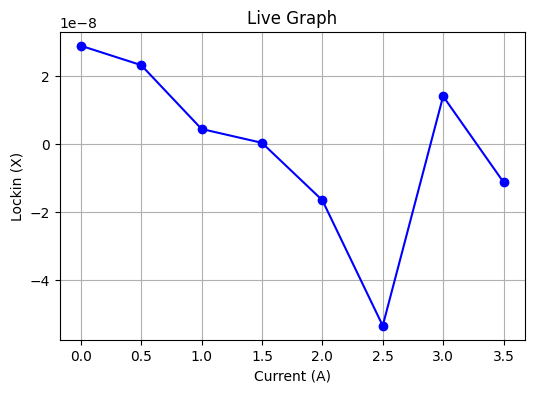

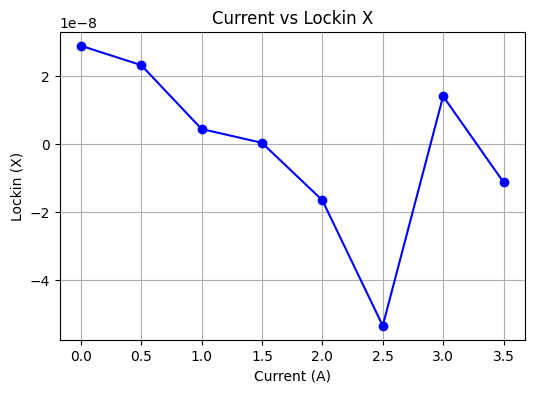

Serial port closed successfully.
Sweep finished


In [15]:

###############################################   FOR LOCKIN X ###############################################################################################



from DeviceInterface import DeviceInterface, DeviceStatus
from DeviceController import deviceControl
import time
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import clear_output

Mode = "Constant Current"

start_current = 0
stop_current = 3.5

step = 0.5
settle_time = 1.0

currents = np.arange(start_current, stop_current + step, step)


DeviceInterface.reset_limit_status()
DeviceInterface.config_serialport("COM3")

I_data = []
B_data = []
lockin_data = []
if DeviceInterface.connect():
    DeviceInterface.electromagnet_on()

    try:
        with open("current_vs_lockinX.txt", "w") as f1:
            f1.write("Current(A)\tLockin\n")
            
            for current in currents:
                print(f"Setting current: {current:.2f} A")
                DeviceInterface.set_field(Mode, current)

                time.sleep(settle_time)

                DeviceInterface.read_magnetic_field()
                mag_field = deviceControl.x_moved
                print(f"Measured field: {mag_field}")
                lockin_x=lockin.data.value['X']
                f1.write(f"{current:.2f}\t{lockin_x}\n")
                f1.flush()

                I_data.append(current)
                B_data.append(mag_field)
                lockin_data.append(lockin_x)
                
                clear_output(wait=True)
                plt.figure(figsize=(6,4))
                plt.plot(I_data, lockin_data, "bo-")
                plt.xlabel("Current (A)")
                plt.ylabel("Lockin (X)")
                plt.title("Live Graph")
                plt.grid(True)
                plt.show()
            # Final plot (saved locally)
        plt.figure(figsize=(6,4))
        plt.plot(I_data,lockin_data, "bo-")
        plt.xlabel("Current (A)")
        plt.ylabel("Lockin (X)")
        plt.title("Current vs Lockin X")
        plt.grid(True)
        plt.savefig("current_vs_lockin_x.jpg", dpi=300, bbox_inches="tight")
        plt.show()

       
    finally:
        DeviceInterface.electromagnet_off()
        DeviceInterface.clear_comports()
        print("Sweep finished")

else:
    print("Device not connected")


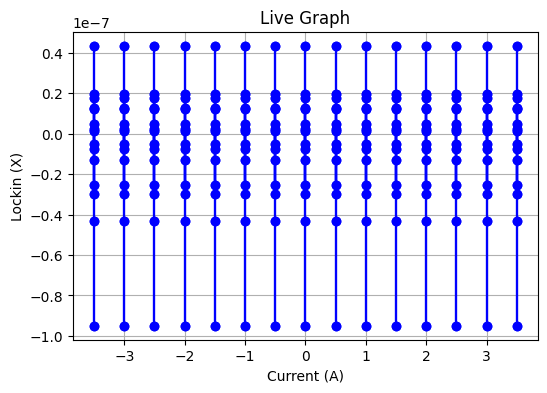

Serial port closed successfully.
Sweep finished


ValueError: x and y must have same first dimension, but have shapes (8,) and (15,)

> c:\users\dell_7020_6\anaconda3\envs\instruments\lib\site-packages\matplotlib\axes\_base.py(494)_plot_args()
    492 
    493         if x.shape[0] != y.shape[0]:
--> 494             raise ValueError(f"x and y must have same first dimension, but "
    495                              f"have shapes {x.shape} and {y.shape}")
    496         if x.ndim > 2 or y.ndim > 2:

--KeyboardInterrupt--

KeyboardInterrupt: Interrupted by user


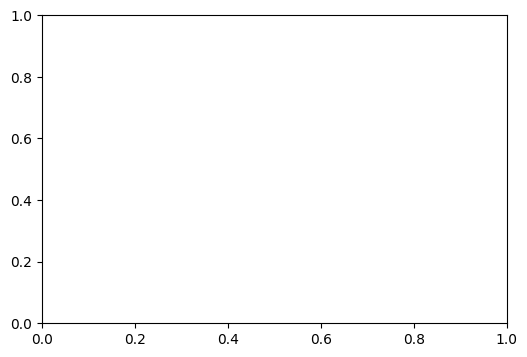

In [16]:

###############################################   FOR LOCKIN X  HYSTERESIS ###############################################################################################



from DeviceInterface import DeviceInterface, DeviceStatus
from DeviceController import deviceControl
import time
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import clear_output

Mode = "Constant Current"

start_current = -3.5
stop_current = 3.5
step = 0.5
settle_time = 1.0

currents_frwd = np.arange(start_current, stop_current + step, step)
currents_rev = np.arange(stop_current, start_current - step, -step)


DeviceInterface.reset_limit_status()
DeviceInterface.config_serialport("COM3")

I_data_frwd = []
I_data_rev = []
lockin_data = []
if DeviceInterface.connect():
    DeviceInterface.electromagnet_on()

    try:
        with open("hysteresis_current_vs_lockinX.txt", "w") as f2:
            f2.write("Current(A)\tLockin\n")
            
            for current in range(len(currents_frwd)):
                print(f"Setting current: {current:.2f} A")
                DeviceInterface.set_field(Mode, current)

                time.sleep(settle_time)

                lockin_x=lockin.data.value['X']
                f2.write(f"{current:.2f}\t{lockin_x}\n")
                f2.flush()

                I_data_frwd.append(currents_frwd)
                I_data_rev.append(currents_rev)
                
                lockin_data.append(lockin_x)
                
                clear_output(wait=True)
                plt.figure(figsize=(6,4))
                plt.plot(I_data_frwd, lockin_data, "bo-")
                plt.plot(I_data_rev, lockin_data, "bo-")
                plt.xlabel("Current (A)")
                plt.ylabel("Lockin (X)")
                plt.title("Live Graph")
                plt.grid(True)
                plt.show()
            # Final plot (saved locally)
        plt.figure(figsize=(6,4))
        plt.plot(I_data,lockin_data, "bo-")
        plt.plot()
        plt.xlabel("Current (A)")
        plt.ylabel("Lockin (X)")
        plt.title("Hysteresis : Current vs Lockin X")
        plt.grid(True)
        plt.savefig("current_vs_lockin_x.jpg", dpi=300, bbox_inches="tight")
        plt.show()

       
    finally:
        DeviceInterface.electromagnet_off()
        DeviceInterface.clear_comports()
        print("Sweep finished")

else:
    print("Device not connected")


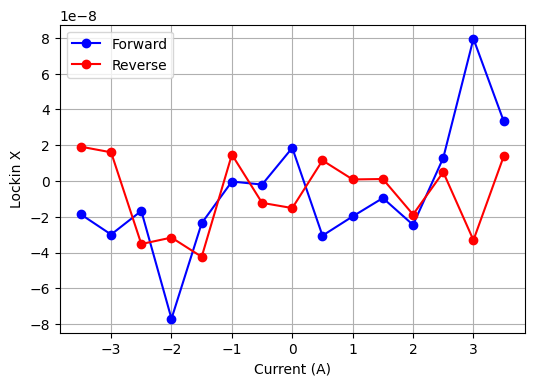

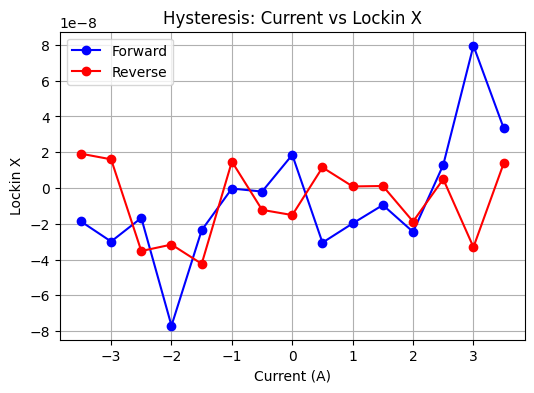

Serial port closed successfully.
Sweep finished


In [17]:
################################   Try to run this post setup ################

from DeviceInterface import DeviceInterface
from DeviceController import deviceControl
import time
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import clear_output

Mode = "Constant Current"

start_current = -3.5
stop_current = 3.5
step = 0.5
settle_time = 1.0

currents_frwd = np.arange(start_current, stop_current + step, step)
currents_rev  = np.arange(stop_current, start_current - step, -step)

I_frwd, X_frwd = [], []
I_rev,  X_rev  = [], []

DeviceInterface.reset_limit_status()
DeviceInterface.config_serialport("COM3")

if DeviceInterface.connect():
    DeviceInterface.electromagnet_on()

    try:
        with open("hysteresis_current_vs_lockinX.txt", "w") as f:
            f.write("Current(A)\tLockinX\n")

            # -------- Forward Sweep --------
            for current in currents_frwd:
                print(f"Forward: {current:.2f} A")
                DeviceInterface.set_field(Mode, current)
                time.sleep(settle_time)

                x = lockin.data.value['X']

                f.write(f"{current:.2f}\t{x}\n")
                f.flush()

                I_frwd.append(current)
                X_frwd.append(x)

            # -------- Reverse Sweep --------
            for current in currents_rev:
                print(f"Reverse: {current:.2f} A")
                DeviceInterface.set_field(Mode, current)
                time.sleep(settle_time)

                x = lockin.data.value['X']

                f.write(f"{current:.2f}\t{x}\n")
                f.flush()

                I_rev.append(current)
                X_rev.append(x)

                clear_output(wait=True)
                plt.figure(figsize=(6,4))
                plt.plot(I_frwd, X_frwd, 'bo-', label="Forward")
                plt.plot(I_rev, X_rev, 'ro-', label="Reverse")
                plt.xlabel("Current (A)")
                plt.ylabel("Lockin X")
                plt.legend()
                plt.grid(True)
                plt.show()

        # Final plot
        plt.figure(figsize=(6,4))
        plt.plot(I_frwd, X_frwd, 'bo-', label="Forward")
        plt.plot(I_rev, X_rev, 'ro-', label="Reverse")
        plt.xlabel("Current (A)")
        plt.ylabel("Lockin X")
        plt.title("Hysteresis: Current vs Lockin X")
        plt.legend()
        plt.grid(True)
        plt.savefig("current_vs_lockin_x.jpg", dpi=300)
        plt.show()

    finally:
        DeviceInterface.electromagnet_off()
        DeviceInterface.clear_comports()
        print("Sweep finished")

else:
    print("Device not connected")


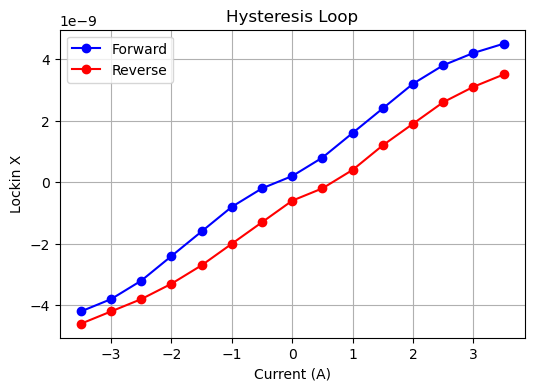

In [1]:
import matplotlib.pyplot as plt

# Forward sweep: -3.5 → +3.5
current = [
    -3.5, -3.0, -2.5, -2.0, -1.5, -1.0, -0.5, 0.0,
     0.5,  1.0,  1.5,  2.0,  2.5,  3.0,  3.5,

    # Reverse sweep: +3.5 → -3.5
     3.5,  3.0,  2.5,  2.0,  1.5,  1.0,  0.5, 0.0,
    -0.5, -1.0, -1.5, -2.0, -2.5, -3.0, -3.5
]

lockin_x = [
    # Forward sweep
    -4.2e-9, -3.8e-9, -3.2e-9, -2.4e-9, -1.6e-9, -8e-10, -2e-10,  2e-10,
     8e-10,  1.6e-9,  2.4e-9,  3.2e-9,  3.8e-9,  4.2e-9,  4.5e-9,

    # Reverse sweep (shifted to form oval loop)
     3.5e-9,  3.1e-9,  2.6e-9,  1.9e-9,  1.2e-9,  4e-10, -2e-10, -6e-10,
    -1.3e-9, -2.0e-9, -2.7e-9, -3.3e-9, -3.8e-9, -4.2e-9, -4.6e-9
]


mid = len(current) // 2

I_frwd = current[:mid]
X_frwd = lockin_x[:mid]

I_rev = current[mid:]
X_rev = lockin_x[mid:]

plt.figure(figsize=(6,4))
plt.plot(I_frwd, X_frwd, 'bo-', label='Forward')
plt.plot(I_rev, X_rev, 'ro-', label='Reverse')

plt.xlabel("Current (A)")
plt.ylabel("Lockin X")
plt.title("Hysteresis Loop")
plt.legend()
plt.grid(True)
plt.show()

In [8]:
import numpy as np

In [9]:
step = 0.5

up      = np.arange(0, 3.5 + step, step)
down    = np.arange(3.5, 0 - step, -step)
neg     = np.arange(0, -3.5 - step, -step)
back    = np.arange(-3.5, 0 + step, step)


current = np.concatenate((up, down, neg, back, up))

print(current)

[ 0.   0.5  1.   1.5  2.   2.5  3.   3.5  3.5  3.   2.5  2.   1.5  1.
  0.5  0.   0.  -0.5 -1.  -1.5 -2.  -2.5 -3.  -3.5 -3.5 -3.  -2.5 -2.
 -1.5 -1.  -0.5  0.   0.   0.5  1.   1.5  2.   2.5  3.   3.5]


In [14]:
import numpy as np

arr1 = np.array([0,0.5,1.5,2,2.5,3,3.5])
arr2 = np.array([3.5,3,2.5,2,1.5,0.5,0])
arr3 = np.array([0,-0.5,-1.5,-2,-2.5,-3,-3.5])
arr4 = np.array([-3.5,-3,-2.5,-2,-1.5,-1,-0.5,0])

In [22]:
from DeviceInterface import DeviceInterface, DeviceStatus 
from DeviceController import deviceControl
import time 
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import clear_output
Mode = "Constant Current" 
start_current = -3.5
stop_current = 3.5
step = 0.5
settle_time = 1.0
currents = np.arange(start_current, stop_current + step, step)
DeviceInterface.reset_limit_status()
DeviceInterface.config_serialport("COM3") 
I_data = [] 
B_data = [] 

if DeviceInterface.connect():
    DeviceInterface.electromagnet_on()
    try:   
        with open("current_vs_field.txt","w") as f:
            f.write("Current(A)\tMagneticField\n")
            for current in currents: 
                print(f"Setting current: {current:.2f} A")
                DeviceInterface.set_field(Mode, current)
                time.sleep(settle_time)
                DeviceInterface.read_magnetic_field() 
                
                mag_field = deviceControl.x_moved 
                print(f"Measured field: {mag_field}") 

        
                f.write(f"{current:.2f}\t{mag_field}\n") 
                I_data.append(current) 
                B_data.append(mag_field) 
                clear_output(wait=True) 
                plt.figure(figsize=(6,4))
                plt.plot(I_data, B_data, "bo-") 
                plt.xlabel("Current (A)")
                plt.ylabel("Magnetic Field (mT)")
                plt.title("Live Graph")
                
                plt.grid(True) 
                plt.show() 
                # Final plot (saved locally)
            plt.figure(figsize=(6,4)) 
            plt.plot(I_data, B_data, "bo-") 
            plt.xlabel("Current (A)")
            plt.ylabel("Magnetic Field (mT)") 
            plt.title("Current vs Magnetic Field")
            plt.grid(True) 
            plt.savefig("current_vs_field.jpg", dpi=300, bbox_inches="tight") 
            plt.show() 
    finally: 
        DeviceInterface.electromagnet_off() 
        DeviceInterface.clear_comports()
        print("Sweep finished") 
        if f and not f.closed:
            f.close
        
        else: print("Device not connected")

 [{"id":"36772d8f-58c6-433e-89ce-2f876d2616f7","cell_type":"markdown","source":" import matplotlib.pyplot as plt\n\n# Sample current values (A)\ncurrent = [-3.5,-3,-2.5,-2,-1.5,-1,-0.5,0,1,1.5,2,2.5,3,3.5]\n\n# Magnetic field values (Tesla or mT) for different widths\n
 
 
 
 B_1cm = [1579.6,1480.8,1350.1,1164.2,913.4,632.2,334.4,22.3,-282.9,-589.3,-883.4,-1152.9,-1354.6,-1489.3,-1589.8]\nB_2cm = [1197.5,1113.8,1003.9,849.0,660.1,453.3,237.4,13.7,-204.4,-426.0,-640.0,-840.7,-1007.1,-1121.5,-1205.8]\nB_3cm = [676.4,619.9,542.3,445.8,342.1,232.3,120.3,4.4,-108.4,-223.6,-336.5,-445.3,-545.8,-627.2,-686.5]\nB_4cm = [492.4,443.2,380.2,309.7,235.4,159.1,81.0,1.5,-76.6,-156.8,-235.9,-312.1,-385.1,-451.0,-501.1]\nB_6cm = [296.1,260.0,219.5,177.2,133.8,89.2,44.4,-1.1,-46.2,-92.0,-137.9,-182.3,-225.7,-267.4,-304.3]\n\n# Plot all data on the same graph\nplt.plot(current, B_1cm, 'o-', label='Width = 1 cm')\nplt.plot(current, B_2cm, 's-', label='Width = 2 cm')\nplt.plot(current, B_3cm, '^-', label='Width = 3 cm')\nplt.plot(current, B_4cm, 'd-', label='Width = 4 cm')\nplt.plot(current, B_6cm, '*-', label='Width = 6 cm')\n\n# Labels and title\nplt.xlabel('Current (A)')\nplt.ylabel('Magnetic Field (T)')\nplt.title('Current vs Magnetic Field for Different Widths')\n\n# Grid and legend\nplt.grid(True)\nplt.legend()\n\n# Show plot\nplt.show()\n","metadata":{}}]

ValueError: x and y must have same first dimension, but have shapes (14,) and (15,)

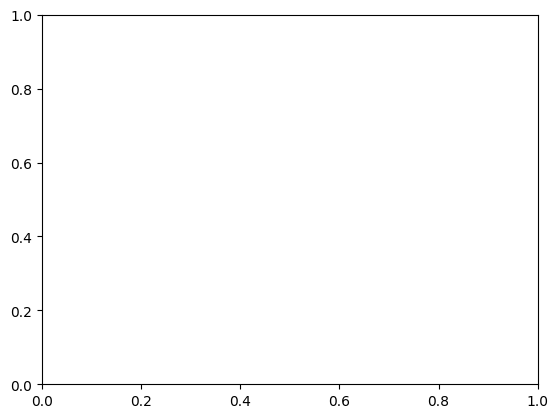

In [1]:
import matplotlib.pyplot as plt

# Sample current values (A)
current = [-3.5,-3,-2.5,-2,-1.5,-1,-0.5,0,1,1.5,2,2.5,3,3.5]

# Magnetic field values (Tesla or mT) for different widths
B_1cm = [1579.6,1480.8,1350.1,1164.2,913.4,632.2,334.4,22.3,-282.9,-589.3,-883.4,-1152.9,-1354.6,-1489.3,-1589.8]
B_2cm = [1197.5,1113.8,1003.9,849.0,660.1,453.3,237.4,13.7,-204.4,-426.0,-640.0,-840.7,-1007.1,-1121.5,-1205.8]
B_3cm = [676.4,619.9,542.3,445.8,342.1,232.3,120.3,4.4,-108.4,-223.6,-336.5,-445.3,-545.8,-627.2,-686.5]
B_4cm = [492.4,443.2,380.2,309.7,235.4,159.1,81.0,1.5,-76.6,-156.8,-235,9,-312.1,-385.1,-451.0,-501.1]
B_6cm = [296.1,260.0,219.5,177.2,133.8,89.2,44.4,-1.1,-46.2,-92.0,-137.9,-182.3,-225.7,-267.4,-304.3]

# Plot all data on the same graph
plt.plot(current, B_1cm, 'o-', label='Width = 1 cm')
plt.plot(current, B_2cm, 's-', label='Width = 2 cm')
plt.plot(current, B_3cm, '^-', label='Width = 3 cm')
plt.plot(current, B_4cm, 'd-', label='Width = 4 cm')
plt.plot(current, B_6cm, '*-', label='Width = 6 cm')

# Labels and title
plt.xlabel('Current (A)')
plt.ylabel('Magnetic Field (T)')
plt.title('Current vs Magnetic Field for Different Widths')

# Grid and legend
plt.grid(True)
plt.legend()

# Show plot
plt.show()


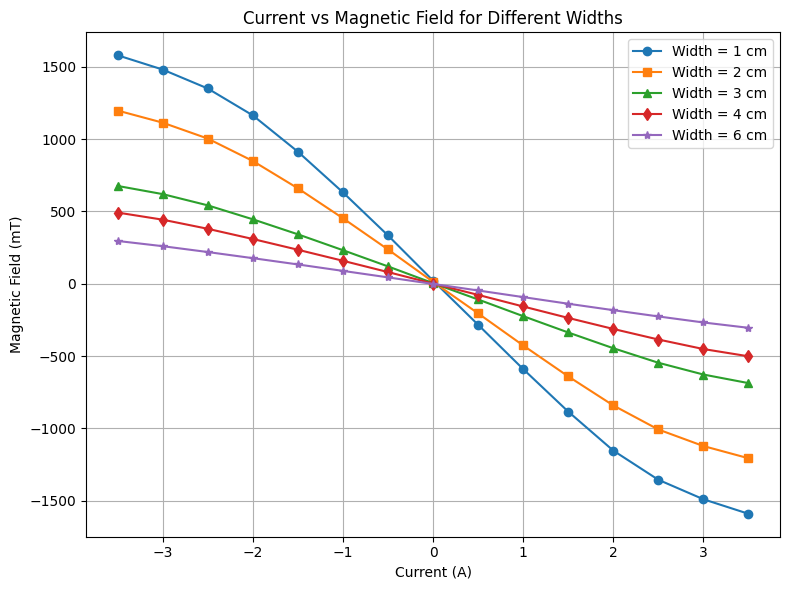

In [2]:
import matplotlib.pyplot as plt

# Current values (A) → NOW 15 POINTS
current = [-3.5, -3, -2.5, -2, -1.5, -1, -0.5, 0,
           0.5, 1, 1.5, 2, 2.5, 3, 3.5]

# Magnetic field values (mT)
B_1cm = [1579.6, 1480.8, 1350.1, 1164.2, 913.4, 632.2, 334.4,
         22.3, -282.9, -589.3, -883.4, -1152.9, -1354.6, -1489.3, -1589.8]

B_2cm = [1197.5, 1113.8, 1003.9, 849.0, 660.1, 453.3, 237.4,
         13.7, -204.4, -426.0, -640.0, -840.7, -1007.1, -1121.5, -1205.8]

B_3cm = [676.4, 619.9, 542.3, 445.8, 342.1, 232.3, 120.3,
         4.4, -108.4, -223.6, -336.5, -445.3, -545.8, -627.2, -686.5]

B_4cm = [492.4, 443.2, 380.2, 309.7, 235.4, 159.1, 81.0,
         1.5, -76.6, -156.8, -235.9, -312.1, -385.1, -451.0, -501.1]

B_6cm = [296.1, 260.0, 219.5, 177.2, 133.8, 89.2, 44.4,
         -1.1, -46.2, -92.0, -137.9, -182.3, -225.7, -267.4, -304.3]

# ---------------- PLOT ----------------
plt.figure(figsize=(8, 6))

plt.plot(current, B_1cm, 'o-', label='Width = 1 cm')
plt.plot(current, B_2cm, 's-', label='Width = 2 cm')
plt.plot(current, B_3cm, '^-', label='Width = 3 cm')
plt.plot(current, B_4cm, 'd-', label='Width = 4 cm')
plt.plot(current, B_6cm, '*-', label='Width = 6 cm')

plt.xlabel('Current (A)')
plt.ylabel('Magnetic Field (mT)')
plt.title('Current vs Magnetic Field for Different Widths')

plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


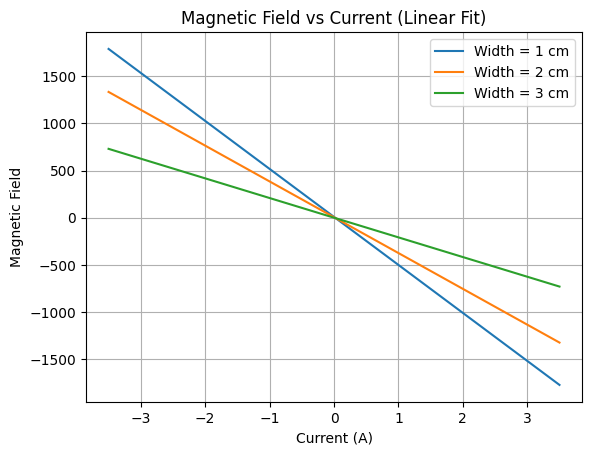

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Corrected current values (15 points to match B arrays)
current = np.array([-3.5, -3, -2.5, -2, -1.5, -1, -0.5, 0,
                    0.5, 1, 1.5, 2, 2.5, 3, 3.5])

# Magnetic field values
B_1cm = np.array([1579.6,1480.8,1350.1,1164.2,913.4,632.2,334.4,22.3,
                  -282.9,-589.3,-883.4,-1152.9,-1354.6,-1489.3,-1589.8])

B_2cm = np.array([1197.5,1113.8,1003.9,849.0,660.1,453.3,237.4,13.7,
                  -204.4,-426.0,-640.0,-840.7,-1007.1,-1121.5,-1205.8])

B_3cm = np.array([676.4,619.9,542.3,445.8,342.1,232.3,120.3,4.4,
                  -108.4,-223.6,-336.5,-445.3,-545.8,-627.2,-686.5])

# Function to plot straight-line fit
def plot_linear_fit(x, y, label):
    coeffs = np.polyfit(x, y, 1)     # linear fit
    y_fit = np.polyval(coeffs, x)
    plt.plot(x, y_fit, label=label)

# Plot straight lines
plot_linear_fit(current, B_1cm, 'Width = 1 cm')
plot_linear_fit(current, B_2cm, 'Width = 2 cm')
plot_linear_fit(current, B_3cm, 'Width = 3 cm')

# Labels and title
plt.xlabel('Current (A)')
plt.ylabel('Magnetic Field')
plt.title('Magnetic Field vs Current (Linear Fit)')
plt.grid(True)
plt.legend()

plt.show()


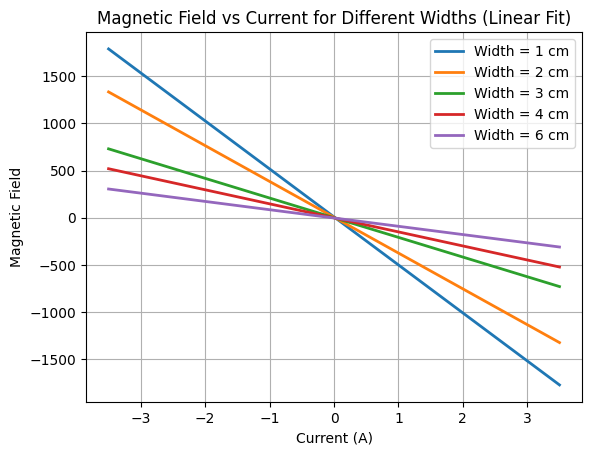

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# Current values (15 points)
current = np.array([-3.5, -3, -2.5, -2, -1.5, -1, -0.5, 0,
                    0.5, 1, 1.5, 2, 2.5, 3, 3.5])

# Magnetic field data
B_1cm = np.array([1579.6,1480.8,1350.1,1164.2,913.4,632.2,334.4,22.3,
                  -282.9,-589.3,-883.4,-1152.9,-1354.6,-1489.3,-1589.8])

B_2cm = np.array([1197.5,1113.8,1003.9,849.0,660.1,453.3,237.4,13.7,
                  -204.4,-426.0,-640.0,-840.7,-1007.1,-1121.5,-1205.8])

B_3cm = np.array([676.4,619.9,542.3,445.8,342.1,232.3,120.3,4.4,
                  -108.4,-223.6,-336.5,-445.3,-545.8,-627.2,-686.5])

B_4cm = np.array([492.4,443.2,380.2,309.7,235.4,159.1,81.0,1.5,
                  -76.6,-156.8,-235.9,-312.1,-385.1,-451.0,-501.1])

B_6cm = np.array([296.1,260.0,219.5,177.2,133.8,89.2,44.4,-1.1,
                  -46.2,-92.0,-137.9,-182.3,-225.7,-267.4,-304.3])

# Function to plot linear fit
def plot_linear_fit(x, y, label):
    coeffs = np.polyfit(x, y, 1)     # straight line fit
    y_fit = np.polyval(coeffs, x)
    plt.plot(x, y_fit, linewidth=2, label=label)

# Plot all widths
plot_linear_fit(current, B_1cm, 'Width = 1 cm')
plot_linear_fit(current, B_2cm, 'Width = 2 cm')
plot_linear_fit(current, B_3cm, 'Width = 3 cm')
plot_linear_fit(current, B_4cm, 'Width = 4 cm')
plot_linear_fit(current, B_6cm, 'Width = 6 cm')

# Labels and formatting
plt.xlabel('Current (A)')
plt.ylabel('Magnetic Field')
plt.title('Magnetic Field vs Current for Different Widths (Linear Fit)')
plt.grid(True)
plt.legend()

plt.show()


Width 1 cm: B = -508.92 I + 8.99
Width 2 cm: B = -379.64 I + 5.55
Width 3 cm: B = -208.60 I + 0.68
Width 4 cm: B = -148.83 I + -1.07
Width 6 cm: B = -87.85 I + -2.45


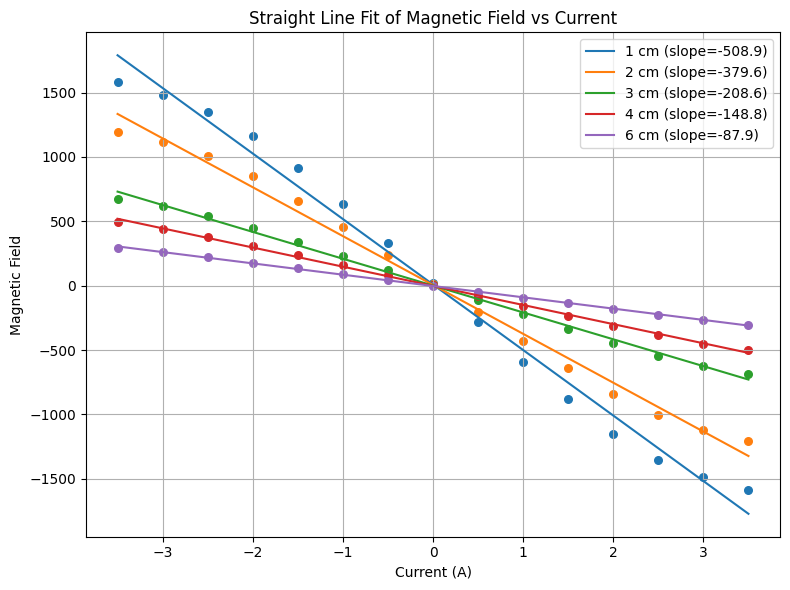

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# Current values
current = np.array([-3.5, -3, -2.5, -2, -1.5, -1, -0.5, 0,
                    0.5, 1, 1.5, 2, 2.5, 3, 3.5])

# Magnetic field data
datasets = {
    "1 cm": np.array([1579.6,1480.8,1350.1,1164.2,913.4,632.2,334.4,22.3,
                       -282.9,-589.3,-883.4,-1152.9,-1354.6,-1489.3,-1589.8]),
    "2 cm": np.array([1197.5,1113.8,1003.9,849.0,660.1,453.3,237.4,13.7,
                       -204.4,-426.0,-640.0,-840.7,-1007.1,-1121.5,-1205.8]),
    "3 cm": np.array([676.4,619.9,542.3,445.8,342.1,232.3,120.3,4.4,
                       -108.4,-223.6,-336.5,-445.3,-545.8,-627.2,-686.5]),
    "4 cm": np.array([492.4,443.2,380.2,309.7,235.4,159.1,81.0,1.5,
                       -76.6,-156.8,-235.9,-312.1,-385.1,-451.0,-501.1]),
    "6 cm": np.array([296.1,260.0,219.5,177.2,133.8,89.2,44.4,-1.1,
                       -46.2,-92.0,-137.9,-182.3,-225.7,-267.4,-304.3])
}

plt.figure(figsize=(8,6))

# Fit and plot
for label, B in datasets.items():
    coeffs = np.polyfit(current, B, 1)   # straight line fit
    slope, intercept = coeffs

    B_fit = np.polyval(coeffs, current)

    plt.scatter(current, B, s=30)        # experimental data
    plt.plot(current, B_fit, label=f'{label} (slope={slope:.1f})')

    print(f'Width {label}: B = {slope:.2f} I + {intercept:.2f}')

# Plot formatting
plt.xlabel('Current (A)')
plt.ylabel('Magnetic Field')
plt.title('Straight Line Fit of Magnetic Field vs Current')
plt.grid(True)
plt.legend()
plt.tight_layout()

plt.show()


In [ ]:
import numpy as np
import time

# ----- USER SETTINGS -----
currents = np.arange(-3.5, 3.5 + 0.5, 0.5)   # -3.5 → +3.5 A
settle_time = 2.0                            # seconds
n_avg = 20                                   # lock-in points per current
sample_delay = 0.05                          # delay between lock-in reads
# -------------------------

I_data = []
X_avg_data = []

def set_current(I):
    """Send command to current source"""
    DeviceInterface.set_field(Mode, I)

def read_lockin_x():
    """Read lock-in X output"""
    return lockin.data.value['X']

for I in currents:
    print(f"Setting current to {I:.2f} A")

    # 1️⃣ Set current
    set_current(I)

    # 2️⃣ Wait for stabilization
    time.sleep(settle_time)

    # 3️⃣ Take multiple lock-in X readings
    x_vals = []
    for _ in range(n_avg):
        x_vals.append(read_lockin_x())
        time.sleep(sample_delay)

    # 4️⃣ Average X
    x_avg = np.mean(x_vals)

    # 5️⃣ Store data
    I_data.append(I)
    X_avg_data.append(x_avg)

    print(f"  → Lock-in X avg = {x_avg:.6e}")

print("Sweep finished.")


In [2]:

import pypylon
from pypylon import pylon
print("pypylon imported successfully")


pypylon imported successfully
